# Student FULL name:DIPESH SUBEDI
# Student number:48803898

Acknowledgement Statement by students: <br>
Please keep one acknowledgment from the following<br>
	I acknowledge that I have not used GenAI (e. g., ChatGPT) in drafting and proofreading of this assignment.<br>




#  Answer to Section 1 (answer in the below cell, please do not add more cells): 

1. The Argyle mine was the world's primary source of pink diamonds, producing more than 90% of the world's supply, which are highly coveted for their rarity.
 https://www.pinkdiamondtradecentre.com.au/about-us/argyle-diamond-mine/ 
3. The Argyle mine in Western Australia closed in November 2020 after 37 years, producing over 865 million carats of rough diamonds during its lifetime.
   https://www.diamondportfolio.com.au/news/rio-tinto-stops-operating-at-argyle-after-37-years/#:~:text=The%20Argyle%20ore%20body%20was,process%20at%20the%20Argyle%20mine.
5. Roughly 250 tonnes of ore were removed to produce a single one-carat diamond at Argyle.
   https://www.ga.gov.au/education/minerals-energy/australian-mineral-facts/diamond?

# Answer to Section 2: add as many cell as needed 

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

In [4]:
#Loading data 
df = pd.read_csv("data.csv", na_values=['', ' ', 'NaN', 'nan', 'na', 'NA', 'null', 'NULL', 'None'])

In [5]:
#displaying first five rows
df.head()

,carat,cut,color,clarity,depth,table,x,y,z,price
0,0.34,Good,Z,SI2,62.2,59.0,4.35,4.34,2.70,349.0
1,0.21,Premium,E,SI1,59.8,61.0,3.89,3.84,2.31,326.0
2,0.23,Good,E,VS1,56.9,65.0,4.05,4.07,2.31,327.0
3,0.29,Premium,I,VS2,62.4,58.0,4.20,4.23,2.63,334.0
4,0.31,Good,J,SI2,63.3,58.0,4.34,4.35,2.75,335.0


In [6]:
#checking the number of rows and columns
df.shape

(55843, 10)

In [7]:
#checking data types  and also the non-null counts in every columns
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 55843 entries, 0 to 55842
Data columns (total 10 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   carat    55840 non-null  float64
 1   cut      55839 non-null  object 
 2   color    55838 non-null  object 
 3   clarity  55841 non-null  object 
 4   depth    55836 non-null  float64
 5   table    55840 non-null  float64
 6   x        55839 non-null  float64
 7   y        55842 non-null  float64
 8   z        55840 non-null  float64
 9   price    55839 non-null  float64
dtypes: float64(7), object(3)
memory usage: 4.3+ MB


In [8]:
#Counting the missing values in every columns
df.isnull().sum()

carat      3
cut        4
color      5
clarity    2
depth      7
table      3
x          4
y          1
z          3
price      4
dtype: int64

In [9]:
# Droping all rows with missing values
df = df.dropna()

# Confirming there is no missing values
df.isnull().sum()

carat      0
cut        0
color      0
clarity    0
depth      0
table      0
x          0
y          0
z          0
price      0
dtype: int64

In [10]:
#Displaying statistical summary
df.describe()

,carat,depth,table,x,y,z,price
count,55809.000000,55809.000000,55809.000000,55809.000000,55809.000000,55809.000000,55809.000000
mean,0.822484,61.690833,57.518278,5.743603,5.746212,3.543951,4129.883657
std,0.508436,1.616280,2.350229,1.145003,1.164481,0.719519,4201.711334
min,0.200000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.400000,61.000000,56.000000,4.710000,4.720000,2.910000,965.000000
50%,0.710000,61.800000,57.000000,5.700000,5.710000,3.530000,2513.000000
75%,1.060000,62.500000,59.000000,6.550000,6.550000,4.040000,5606.000000
max,5.010000,79.000000,95.000000,10.740000,58.900000,31.800000,19996.000000


In [11]:
# Checking for duplicate rows
print(df.duplicated().sum())

# Droping the duplicate rows
df = df.drop_duplicates()

147


In [12]:
# Keep only valid cut categories
valid_cuts = ['Fair', 'Good', 'Very Good', 'Premium', 'Ideal']
df = df[df['cut'].isin(valid_cuts)]

# Confirm the fix
print(df['cut'].unique())

['Good' 'Premium' 'Very Good' 'Fair' 'Ideal']


In [13]:
# Calculating Q1 and Q3 for price
percentile25 = df['price'].quantile(0.25)
percentile75 = df['price'].quantile(0.75)

# Calculating IQR
iqr = percentile75 - percentile25

# Calculating upper and lower limits
upper_limit = percentile75 + 1.5 * iqr
lower_limit = percentile25 - 1.5 * iqr

print('Upper limit is: ' + str(upper_limit))
print('Lower limit is: ' + str(lower_limit))


print(df[df['price'] > upper_limit])
print(df[df['price'] < lower_limit])

Upper limit is: 12570.0
Lower limit is: -5998.0
       carat      cut color clarity  depth  table     x     y     z    price
24326   1.51  Premium     G     VS2   62.0   57.0  7.38  7.33  4.56  12571.0
24327   2.03    Ideal     G     SI2   62.2   57.0  8.09  8.06  5.03  12573.0
24328   1.50    Ideal     G     VS1   61.0   57.0  7.32  7.40  4.49  12576.0
24329   2.00  Premium     D     SI2   59.3   62.0  8.12  8.06  4.80  12576.0
24330   1.27    Ideal     F    VVS2   62.2   54.0  6.92  6.95  4.31  12576.0
...      ...      ...   ...     ...    ...    ...   ...   ...   ...      ...
55805   2.89     Fair     Z    VVS2   56.2   53.0  6.27  6.49  4.89  13886.0
55809   1.14  Premium     Z    VVS1   62.7   59.0  8.84  8.19  3.64  13670.0
55812   1.23     Fair     Z     SI2   59.5   55.0  5.77  6.66  3.37  16066.0
55814   1.20    Ideal     Z    VVS1   64.4   64.0  7.38  6.20  2.24  19119.0
55818   1.25  Premium     Z      I1   64.7   55.0  3.87  8.21  3.42  13751.0

[3728 rows x 10 columns]
Em

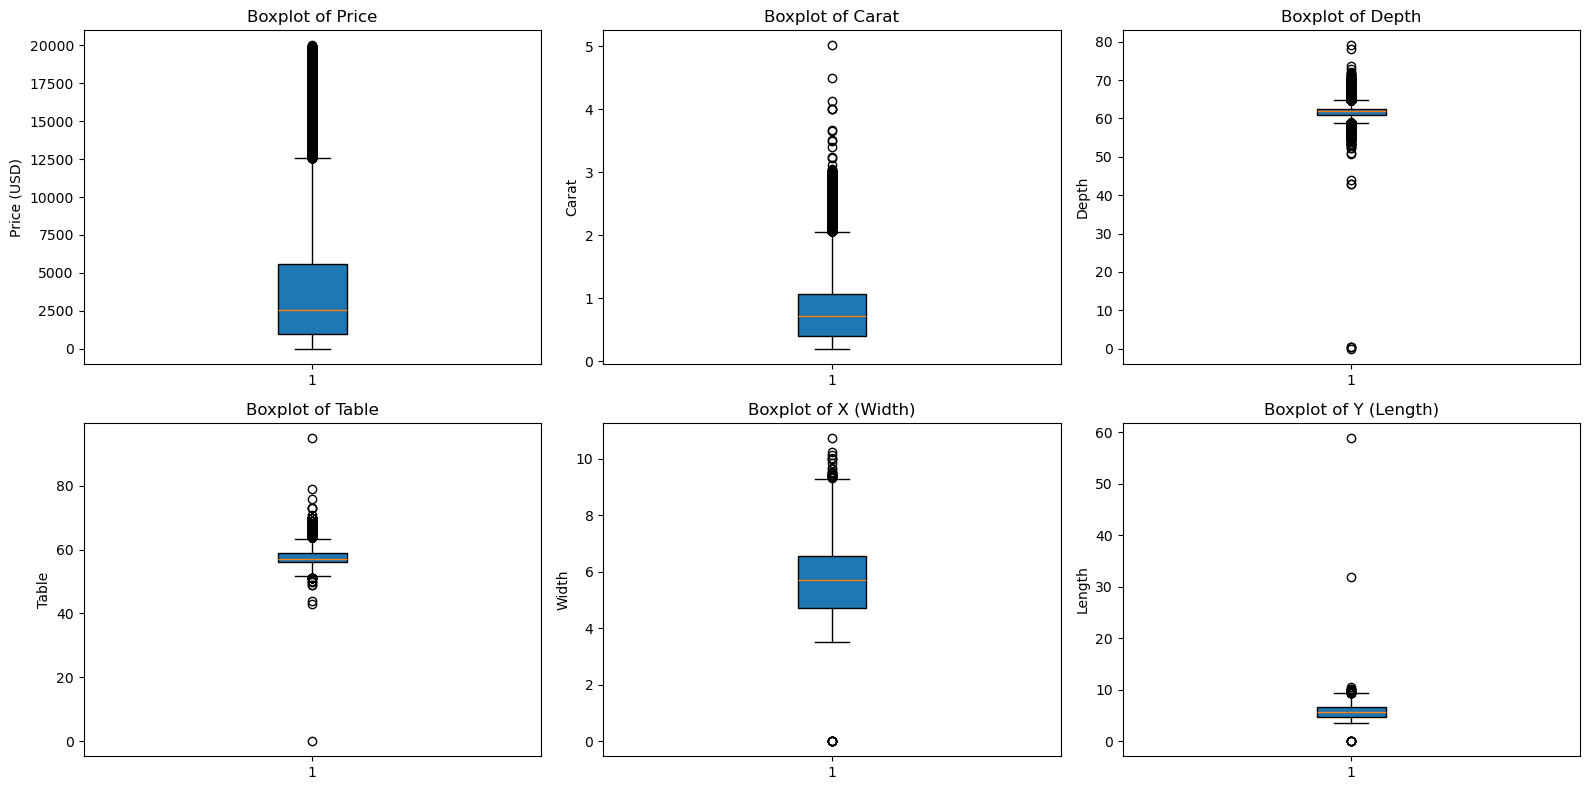

In [14]:
# Boxplots to visualise outliers across all numerical columns
plt.figure(figsize=(16, 8))

plt.subplot(2, 3, 1)
plt.boxplot(df['price'], patch_artist=True)
plt.title('Boxplot of Price')
plt.ylabel('Price (USD)')

plt.subplot(2, 3, 2)
plt.boxplot(df['carat'], patch_artist=True)
plt.title('Boxplot of Carat')
plt.ylabel('Carat')

plt.subplot(2, 3, 3)
plt.boxplot(df['depth'], patch_artist=True)
plt.title('Boxplot of Depth')
plt.ylabel('Depth')

plt.subplot(2, 3, 4)
plt.boxplot(df['table'], patch_artist=True)
plt.title('Boxplot of Table')
plt.ylabel('Table')

plt.subplot(2, 3, 5)
plt.boxplot(df['x'], patch_artist=True)
plt.title('Boxplot of X (Width)')
plt.ylabel('Width')

plt.subplot(2, 3, 6)
plt.boxplot(df['y'], patch_artist=True)
plt.title('Boxplot of Y (Length)')
plt.ylabel('Length')

plt.tight_layout()
plt.show()

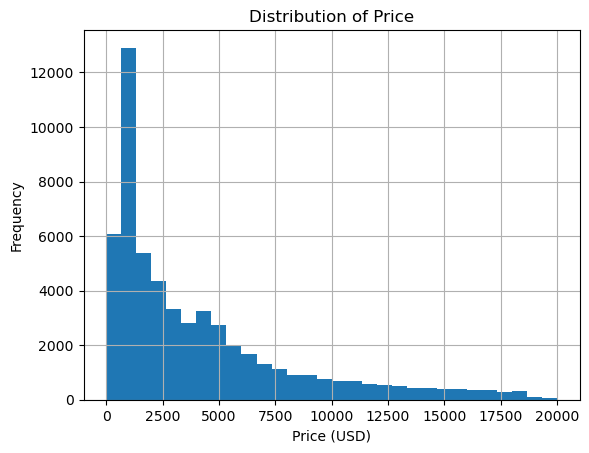

In [15]:
# Histogram to visualise distribution of price
df['price'].hist(bins=30)
plt.title('Distribution of Price')
plt.xlabel('Price (USD)')
plt.ylabel('Frequency')
plt.show()

In [16]:
# Fixing the outliers for price
percentile25 = df['price'].quantile(0.25)
percentile75 = df['price'].quantile(0.75)
iqr = percentile75 - percentile25
upper_limit = percentile75 + 1.5 * iqr
lower_limit = percentile25 - 1.5 * iqr
median_price = df['price'].median()
df.loc[df['price'] > upper_limit, 'price'] = median_price
df.loc[df['price'] < lower_limit, 'price'] = median_price

# Fixing outliers for carat
percentile25 = df['carat'].quantile(0.25)
percentile75 = df['carat'].quantile(0.75)
iqr = percentile75 - percentile25
upper_limit = percentile75 + 1.5 * iqr
lower_limit = percentile25 - 1.5 * iqr
median_carat = df['carat'].median()
df.loc[df['carat'] > upper_limit, 'carat'] = median_carat
df.loc[df['carat'] < lower_limit, 'carat'] = median_carat

# Fixing outliers for depth
percentile25 = df['depth'].quantile(0.25)
percentile75 = df['depth'].quantile(0.75)
iqr = percentile75 - percentile25
upper_limit = percentile75 + 1.5 * iqr
lower_limit = percentile25 - 1.5 * iqr
median_depth = df['depth'].median()
df.loc[df['depth'] > upper_limit, 'depth'] = median_depth
df.loc[df['depth'] < lower_limit, 'depth'] = median_depth

# Fixing outliers for table
percentile25 = df['table'].quantile(0.25)
percentile75 = df['table'].quantile(0.75)
iqr = percentile75 - percentile25
upper_limit = percentile75 + 1.5 * iqr
lower_limit = percentile25 - 1.5 * iqr
median_table = df['table'].median()
df.loc[df['table'] > upper_limit, 'table'] = median_table
df.loc[df['table'] < lower_limit, 'table'] = median_table

# Fixing outliers for x (width)
percentile25 = df['x'].quantile(0.25)
percentile75 = df['x'].quantile(0.75)
iqr = percentile75 - percentile25
upper_limit = percentile75 + 1.5 * iqr
lower_limit = percentile25 - 1.5 * iqr
median_x = df['x'].median()
df.loc[df['x'] > upper_limit, 'x'] = median_x
df.loc[df['x'] < lower_limit, 'x'] = median_x

# Fixing outliers for y (length)
percentile25 = df['y'].quantile(0.25)
percentile75 = df['y'].quantile(0.75)
iqr = percentile75 - percentile25
upper_limit = percentile75 + 1.5 * iqr
lower_limit = percentile25 - 1.5 * iqr
median_y = df['y'].median()
df.loc[df['y'] > upper_limit, 'y'] = median_y
df.loc[df['y'] < lower_limit, 'y'] = median_y

# Fixing outliers for z (height)
percentile25 = df['z'].quantile(0.25)
percentile75 = df['z'].quantile(0.75)
iqr = percentile75 - percentile25
upper_limit = percentile75 + 1.5 * iqr
lower_limit = percentile25 - 1.5 * iqr
median_z = df['z'].median()
df.loc[df['z'] > upper_limit, 'z'] = median_z
df.loc[df['z'] < lower_limit, 'z'] = median_z

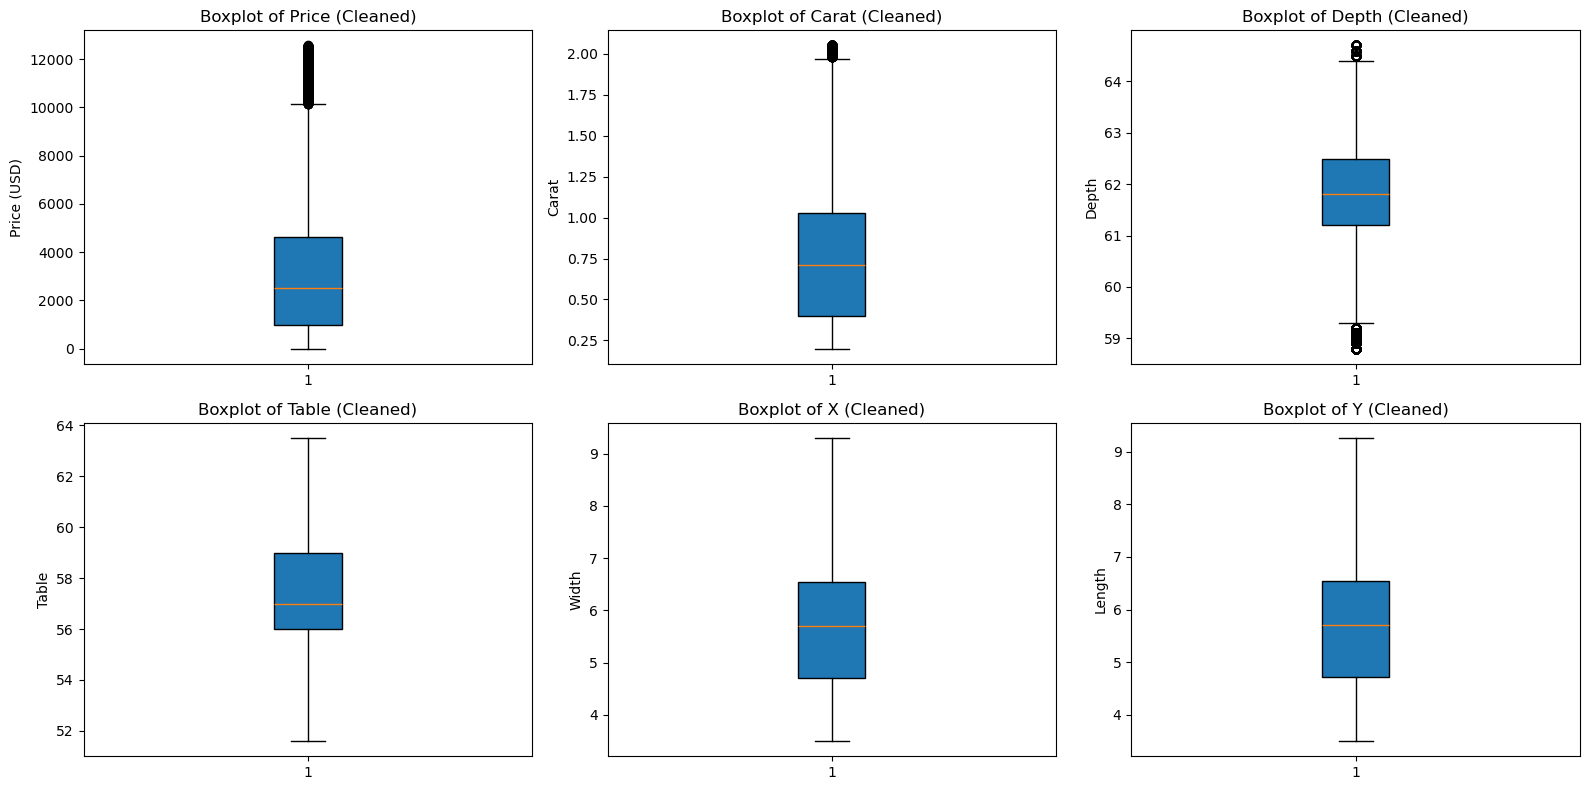

In [17]:
# Boxplots after outlier treatment to check they are fixed
plt.figure(figsize=(16, 8))

plt.subplot(2, 3, 1)
plt.boxplot(df['price'], patch_artist=True)
plt.title('Boxplot of Price (Cleaned)')
plt.ylabel('Price (USD)')

plt.subplot(2, 3, 2)
plt.boxplot(df['carat'], patch_artist=True)
plt.title('Boxplot of Carat (Cleaned)')
plt.ylabel('Carat')

plt.subplot(2, 3, 3)
plt.boxplot(df['depth'], patch_artist=True)
plt.title('Boxplot of Depth (Cleaned)')
plt.ylabel('Depth')

plt.subplot(2, 3, 4)
plt.boxplot(df['table'], patch_artist=True)
plt.title('Boxplot of Table (Cleaned)')
plt.ylabel('Table')

plt.subplot(2, 3, 5)
plt.boxplot(df['x'], patch_artist=True)
plt.title('Boxplot of X (Cleaned)')
plt.ylabel('Width')

plt.subplot(2, 3, 6)
plt.boxplot(df['y'], patch_artist=True)
plt.title('Boxplot of Y (Cleaned)')
plt.ylabel('Length')

plt.tight_layout()
plt.show()

# Answer to Section 3 - one cell per visualisation, please add one comment before each code explaining what does the visulisaiton tend to present

## How does carat affect the price of diamonds? ##

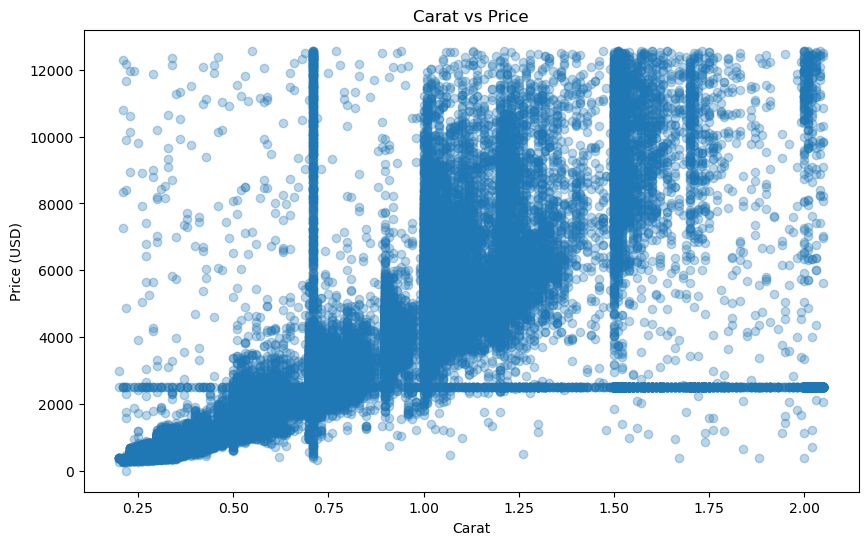

In [18]:
# Scatter plot to show the relationship between carat and price
plt.figure(figsize=(10, 6))
plt.scatter(df['carat'], df['price'], alpha=0.3)
plt.title('Carat vs Price')
plt.xlabel('Carat')
plt.ylabel('Price (USD)')
plt.show()

## Which cut type has the highest average price? ##

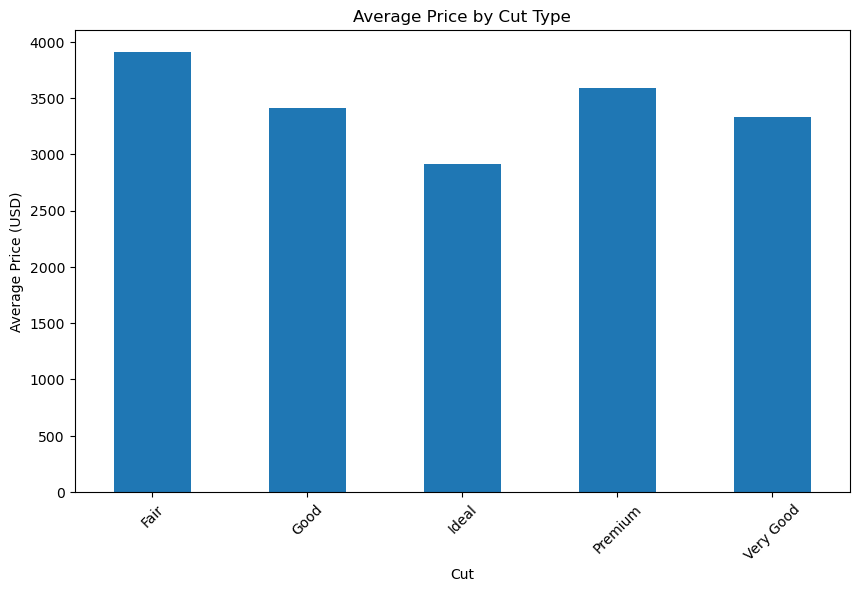

In [19]:
# Bar chart to show average price by cut type
cut_price = df.groupby('cut')['price'].mean()
plt.figure(figsize=(10, 6))
cut_price.plot(kind='bar')
plt.title('Average Price by Cut Type')
plt.xlabel('Cut')
plt.ylabel('Average Price (USD)')
plt.xticks(rotation=45)
plt.show()

## How does clarity impact diamond price? ##

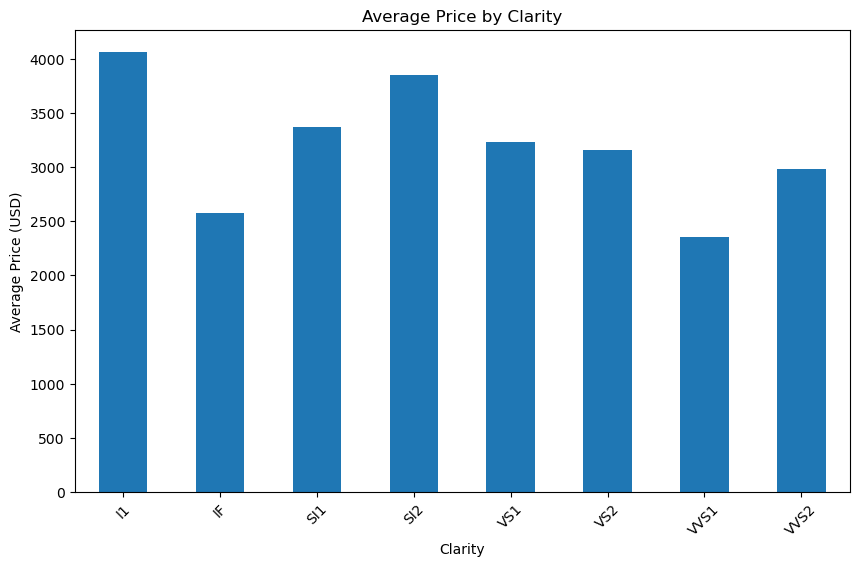

In [20]:
# Bar chart to show average price by clarity
clarity_price = df.groupby('clarity')['price'].mean()
plt.figure(figsize=(10, 6))
clarity_price.plot(kind='bar')
plt.title('Average Price by Clarity')
plt.xlabel('Clarity')
plt.ylabel('Average Price (USD)')
plt.xticks(rotation=45)
plt.show()

## What is the distribution of diamond prices? ##

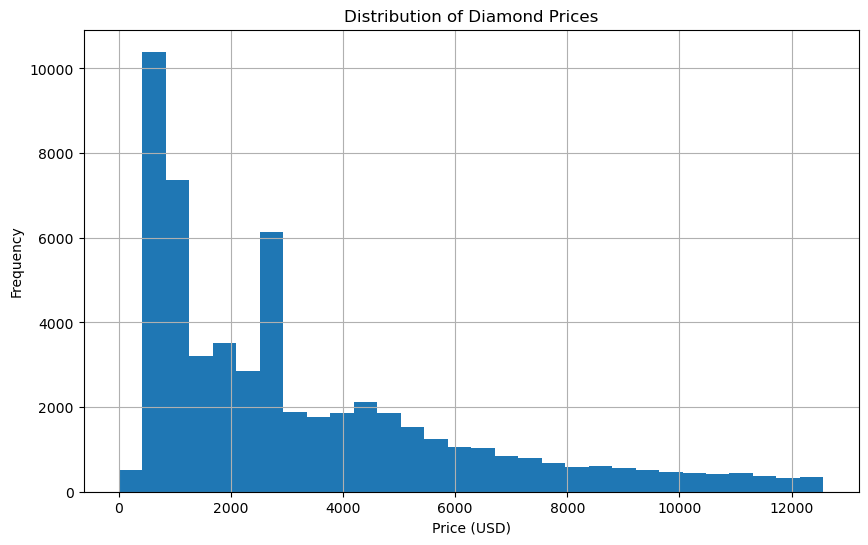

In [21]:
# Histogram to show the distribution of diamond prices
plt.figure(figsize=(10, 6))
df['price'].hist(bins=30)
plt.title('Distribution of Diamond Prices')
plt.xlabel('Price (USD)')
plt.ylabel('Frequency')
plt.show()

# Answer to Section 4, two cells per test

## One Sample Test ##

Null Hypothesis (H0): μ = 4000 (The mean price of diamonds is equal to $4000)

Alternative Hypothesis (H1): μ ≠ 4000 (The mean price of diamonds is different from $4000)

Significance level = 0.05


In [22]:
# Perform one-sample t-test
population_mean = 4000

t_statistic, p_value = stats.ttest_1samp(df['price'], population_mean)

print("t-statistic:", t_statistic)
print("p-value:", p_value)

t-statistic: -61.260442480992914
p-value: 0.0


In [23]:
alpha = 0.05

if p_value < alpha:
    print("Reject the null hypothesis. The mean price is significantly different from $4000.")
else:
    print("Fail to reject the null hypothesis. The data does not provide sufficient evidence that the mean price is different from $4000.")

Reject the null hypothesis. The mean price is significantly different from $4000.


## Two Sample T-Test (Two-Sided) ##

Null Hypothesis(H0): Ideal = Premium (The mean price of Ideal and Premium cut diamonds are equal)

Alternative Hypothesis(H1): Ideal ≠ Premium (The mean price of Ideal and Premium cut diamonds are different)

Significance level = 0.05

In [24]:
# performing two sample t-test (two-sided)
group_ideal = df[df['cut'] == 'Ideal']['price']
group_premium = df[df['cut'] == 'Premium']['price']

t_statistic, p_value = stats.ttest_ind(group_ideal, group_premium, alternative='two-sided')

print("t-statistic:", t_statistic)
print("p-value:", p_value)

t-statistic: -22.053661041739808
p-value: 4.506648682219257e-107


In [26]:
alpha = 0.05

if p_value < alpha:
    print("Reject the null hypothesis. There is a significant difference between the mean price of Ideal and Premium cut diamonds.")
else:
    print("Fail to reject the null hypothesis. There is no significant difference between the mean price of Ideal and Premium cut diamonds.")

Reject the null hypothesis. There is a significant difference between the mean price of Ideal and Premium cut diamonds.


## Two Sample T-Test (Upper-Tailed) ##

Null Hypothesis (H0): Fair ≤  Ideal (The mean price of Fair cut diamonds is less than or equal to Ideal)

Alternative Hypothesis (H1):  Fair >  Ideal (The mean price of Fair cut diamonds is greater than Ideal)

Significance level = 0.05

In [27]:
# Perform two-sample t-test (upper-tailed)
group_fair = df[df['cut'] == 'Fair']['price']
group_ideal = df[df['cut'] == 'Ideal']['price']

t_statistic, p_value = stats.ttest_ind(group_fair, group_ideal, alternative='greater')

print("t-statistic:", t_statistic)
print("p-value:", p_value)

t-statistic: 15.147569023097052
p-value: 6.83795101300712e-52


In [28]:
alpha = 0.05

if p_value < alpha:
    print("Reject the null hypothesis. The mean price of Fair cut diamonds is significantly greater than Ideal cut diamonds.")
else:
    print("Fail to reject the null hypothesis. There is no sufficient evidence that Fair cut diamonds are priced higher than Ideal cut diamonds.")

Reject the null hypothesis. The mean price of Fair cut diamonds is significantly greater than Ideal cut diamonds.
